# Arbol de Decision para Regresion

## Objetivo
Implementar y evaluar un modelo de Arbol de Decision para predecir tasas de cambio.
El modelo predecira valores continuos (tasas de cambio) utilizando variables historicas.

In [1]:
# Celda 1: Configuracion del entorno
import sys
import os

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from dotenv import load_dotenv
load_dotenv(os.path.join(PROJECT_ROOT, '.env.local'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Celda 2: Carga de datos
import psycopg2

def get_connection():
    host = os.getenv('DB_HOST', 'postgres')
    port = os.getenv('DB_PORT', '5432')
    return psycopg2.connect(
        host=host,
        port=port,
        dbname=os.getenv('DB_NAME', 'exchange_db'),
        user=os.getenv('DB_USER', 'postgres'),
        password=os.getenv('DB_PASSWORD', 'postgres'),
        sslmode='disable'
    )

conn = get_connection()

query = """
SELECT 
    er.id,
    c1.code AS base_currency,
    c2.code AS target_currency,
    er.rate,
    er.timestamp
FROM exchange_rates er
JOIN currencies c1 ON er.base_currency_id = c1.id
JOIN currencies c2 ON er.target_currency_id = c2.id
ORDER BY er.timestamp;
"""

df = pd.read_sql(query, conn)
conn.close()
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.head()


,id,base_currency,target_currency,rate,timestamp
0,167,USD,USD,1.020804,2026-04-10 03:37:41.460585+00:00
1,168,USD,AED,3.754758,2026-04-10 03:37:41.460585+00:00
2,169,USD,AFN,66.290639,2026-04-10 03:37:41.460585+00:00
3,170,USD,ALL,79.882348,2026-04-10 03:37:41.460585+00:00
4,171,USD,AMD,376.836419,2026-04-10 03:37:41.460585+00:00


## Preparacion de Datos

In [3]:
# Celda 3: Feature Engineering
df_model = df.copy()
df_model = df_model.sort_values(['target_currency', 'timestamp'])

df_model['rate_lag1'] = df_model.groupby('target_currency')['rate'].shift(1)
df_model['rate_lag2'] = df_model.groupby('target_currency')['rate'].shift(2)
df_model['rate_lag3'] = df_model.groupby('target_currency')['rate'].shift(3)
df_model['rate_lag5'] = df_model.groupby('target_currency')['rate'].shift(5)
df_model['rate_lag7'] = df_model.groupby('target_currency')['rate'].shift(7)

df_model['rate_change_1'] = df_model['rate'] - df_model['rate_lag1']
df_model['rate_change_3'] = df_model['rate'] - df_model['rate_lag3']
df_model['pct_change_1'] = df_model['rate_change_1'] / df_model['rate_lag1'] * 100

df_model['rolling_mean_3'] = df_model['rate'].rolling(3).mean()
df_model['rolling_std_3'] = df_model['rate'].rolling(3).std()
df_model['rolling_mean_7'] = df_model['rate'].rolling(7).mean()

df_model = df_model.dropna(subset=['rate_lag1'])
df_model = df_model.fillna(0)
print(f"Forma del dataset: {df_model.shape}")

(3818, 16)

## Entrenamiento del Modelo

In [4]:
# Celda 4: Division de datos
features = ['rate_lag1', 'rate_lag2', 'rate_lag3', 'rate_lag5', 'rate_lag7',
            'rate_change_1', 'rate_change_3', 'pct_change_1',
            'rolling_mean_3', 'rolling_std_3', 'rolling_mean_7']

X = df_model[features]
y = df_model['rate']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Datos de entrenamiento: {X_train.shape[0]}")
print(f"Datos de prueba: {X_test.shape[0]}")

Datos de entrenamiento: 3054
Datos de prueba: 764


In [5]:
# Celda 5: Entrenamiento del Arbol de Regresion
dt_regressor = DecisionTreeRegressor(
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_regressor.fit(X_train, y_train)

y_pred = dt_regressor.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Metricas del Modelo:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

Metricas del Modelo:
RMSE: 2639.2921
MAE: 263.5472
R2 Score: 0.9994


## Validacion Cruzada

In [6]:
# Celda 6: Cross-Validation
cv_scores = cross_val_score(dt_regressor, X, y, cv=5, scoring='neg_mean_squared_error')
cv_rmse = np.sqrt(-cv_scores)

print("Validacion Cruzada (5 folds):")
print(f"RMSE por fold: {cv_rmse}")
print(f"RMSE promedio: {cv_rmse.mean():.4f} (+/- {cv_rmse.std():.4f})")

Validacion Cruzada (5 folds):
RMSE por fold: [1.13622941e+02 9.43363330e+02 1.95529526e+05 4.50906796e+02
 6.85248290e+02]
RMSE promedio: 39544.5335 (+/- 77992.9750)


## Analisis de Feature Importance

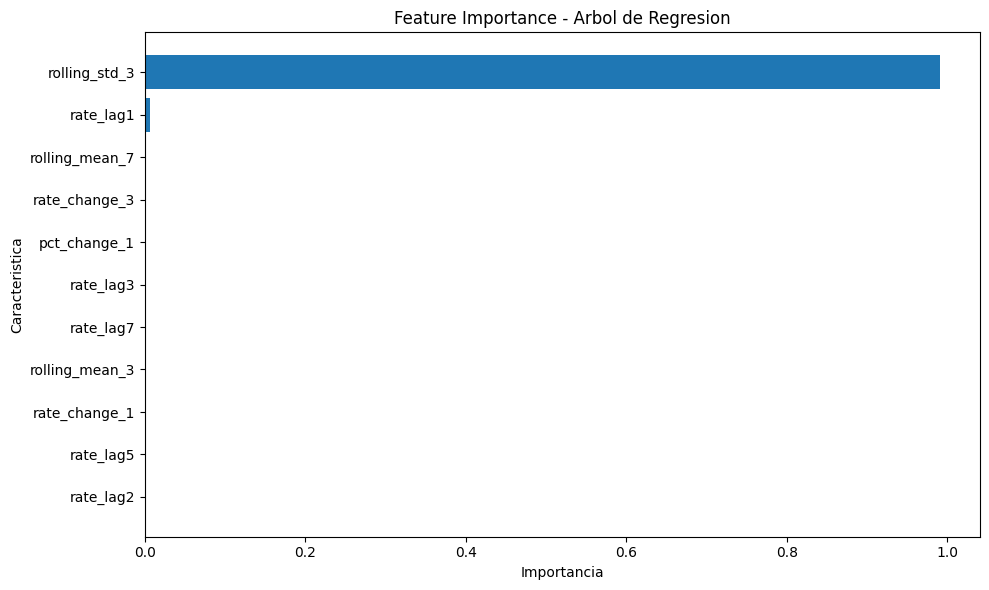

,feature,importance
9,rolling_std_3,9.911077e-01
0,rate_lag1,6.717421e-03
10,rolling_mean_7,1.682828e-03
6,rate_change_3,3.639142e-04
7,pct_change_1,8.403595e-05
2,rate_lag3,3.512229e-05
4,rate_lag7,7.244664e-06
8,rolling_mean_3,1.239412e-06
5,rate_change_1,3.150034e-07
3,rate_lag5,2.262510e-07


In [7]:
# Celda 7: Feature Importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': dt_regressor.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'], feature_importance['importance'])
plt.xlabel('Importancia')
plt.ylabel('Caracteristica')
plt.title('Feature Importance - Arbol de Regresion')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

feature_importance

## Optimizacion de Hiperparametros

In [8]:
# Celda 8: Busqueda de mejores parametros
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [5, 10, 20],
    'min_samples_leaf': [2, 5, 10]
}

grid_search = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Mejores parametros:", grid_search.best_params_)
print("Mejor RMSE:", np.sqrt(-grid_search.best_score_))

Mejores parametros: {'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 10}
Mejor RMSE: 19168.275857093744


In [9]:
# Celda 9: Modelo optimizado
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)

rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
mae_best = mean_absolute_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print("Metricas del Modelo Optimizado:")
print(f"RMSE: {rmse_best:.4f}")
print(f"MAE: {mae_best:.4f}")
print(f"R2 Score: {r2_best:.4f}")

Metricas del Modelo Optimizado:
RMSE: 1938.8015
MAE: 176.1402
R2 Score: 0.9997


## Conclusion

In [10]:
# Celda 10: Resumen
resultado = pd.DataFrame({
    'Modelo': ['Arbol Regresion Default', 'Arbol Regresion Optimizado'],
    'RMSE': [rmse, rmse_best],
    'MAE': [mae, mae_best],
    'R2': [r2, r2_best]
})
resultado

,Modelo,RMSE,MAE,R2
0,Arbol Regresion Default,2639.292110,263.547205,0.999428
1,Arbol Regresion Optimizado,1938.801526,176.140182,0.999691


In [11]:
# Celda 11: Guardar modelo
import joblib

joblib.dump(best_model, 'arbol_regresion_model.pkl')
print("Modelo guardado: arbregresionmodel.pkl")

Modelo guardado: arbregresionmodel.pkl
